# NeurIPS Twelve-Head Heatmaps

This notebook extracts selected heads from the frame-to-frame attention tensors and renders a compact grouped NeurIPS-style figure with a shared color scale.


In [23]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import TwoSlopeNorm

mpl.rcParams.update({
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
    "font.size": 8,
    "axes.titlesize": 6,
    "axes.labelsize": 8,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.0,
    "ytick.major.size": 2.0,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.01,
})


In [24]:
HEAD_GROUPS = [
    {
        "group_title": "Anchor Head",
        "specs": [
            {"layer": 3, "head": 5, "title": "L3H5"},
            {"layer": 26, "head": 2, "title": "L26H2"},
            {"layer": 3, "head": 5, "title": "L3H5"},
            {"layer": 26, "head": 2, "title": "L26H2"},
        ],
    },
    {
        "group_title": "Veil Head",
        "specs": [
            {"layer": 8, "head": 4, "title": "L8H4"},
            {"layer": 21, "head": 8, "title": "L21H8"},
            {"layer": 8, "head": 4, "title": "L8H4"},
            {"layer": 21, "head": 8, "title": "L21H8"},
        ],
    },
    {
        "group_title": "Wave Head",
        "specs": [
            {"layer": 5, "head": 1, "title": "L5H1"},
            {"layer": 21, "head": 11, "title": "L21H11"},
            {"layer": 5, "head": 1, "title": "L5H1"},
            {"layer": 21, "head": 11, "title": "L21H11"},
        ],
    },
]

# DATA_DIR = Path('../../data/26Mar26-PyramidForcing-frames72')
ROW_DATA_DIRS = {
    'top': Path('../../data/26Mar26-PyramidForcing-frames72/eagle'),
    'bottom': Path('../../data/26Mar26-PyramidForcing-frames72/castle'),
}
OUTPUT_DIR = Path('../../figures/26Mar26-PyramidForcing-Frames72')
OUTPUT_STEM = 'neurips_twelve_head_heatmaps'
FIGSIZE = (5.50, 2.2)  # width, height in inches
CMAP = 'RdBu_r'
TICK_POSITIONS = [0, 36, 71]
COLOR_MIN = -18.0
COLOR_MAX = 18.0
SHOW_COLORBAR = True


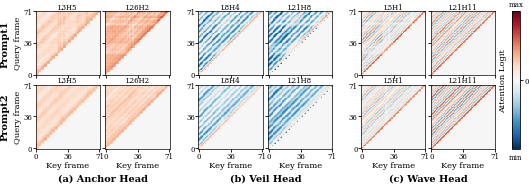

Saved PDF: ../../figures/26Mar26-PyramidForcing-Frames72/neurips_twelve_head_heatmaps.pdf
Saved PNG: ../../figures/26Mar26-PyramidForcing-Frames72/neurips_twelve_head_heatmaps.png
Fixed range: [-18.000, 0.000, 18.000]


In [25]:
for group in HEAD_GROUPS:
    if len(group['specs']) != 4:
        raise ValueError(f"{group['group_title']} must define exactly 4 specs")

if set(ROW_DATA_DIRS) != {'top', 'bottom'}:
    raise ValueError("ROW_DATA_DIRS must define exactly 'top' and 'bottom' data directories")

records_by_group = []
for group in HEAD_GROUPS:
    group_records = []
    for spec_idx, spec in enumerate(group['specs']):
        row_key = 'top' if spec_idx < 2 else 'bottom'
        data_dir = ROW_DATA_DIRS[row_key]
        data_path = data_dir / f"layer{spec['layer']}.pt"
        data = torch.load(data_path, map_location='cpu', weights_only=True)
        full_frame_attention = data['full_frame_attention']
        if spec['head'] < 0 or spec['head'] >= full_frame_attention.shape[0]:
            raise ValueError(
                f"Head {spec['head']} is out of range for {data_path}; "
                f"available heads: 0-{full_frame_attention.shape[0] - 1}"
            )
        attn_map = full_frame_attention[spec['head']].float().numpy()
        group_records.append({
            'title': spec['title'],
            'layer': spec['layer'],
            'head': spec['head'],
            'num_frames': int(data['num_frames']),
            'row_key': row_key,
            'data_dir': data_dir,
            'attn_map': attn_map,
        })
    records_by_group.append({
        'group_title': group['group_title'],
        'records': group_records,
    })

vmin = COLOR_MIN
vmax = COLOR_MAX
norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

fig = plt.figure(figsize=FIGSIZE)
grid = fig.add_gridspec(
    2,
    8,
    left=0.060,
    right=0.895,
    bottom=0.135,
    top=0.900,
    width_ratios=[1, 1, 0.28, 1, 1, 0.28, 1, 1],
    wspace=0.105,
    hspace=0.120,
)
plot_cols = [0, 1, 3, 4, 6, 7]
axes = np.empty((2, 6), dtype=object)
for row in range(2):
    for col, grid_col in enumerate(plot_cols):
        axes[row, col] = fig.add_subplot(grid[row, grid_col])
image = None
for group_idx, group in enumerate(records_by_group):
    col_offset = group_idx * 2
    for item_idx, item in enumerate(group['records']):
        row = item_idx // 2
        col = col_offset + (item_idx % 2)
        ax = axes[row, col]
        ax.set_anchor('S' if row == 0 else 'N')
        image = ax.imshow(
            item['attn_map'],
            cmap=CMAP,
            norm=norm,
            origin='lower',
            aspect='equal',
            interpolation='nearest',
        )
        ax.set_title(item['title'], loc='center', pad=0.5, fontsize=5)
        ax.set_xticks(TICK_POSITIONS)
        ax.set_yticks(TICK_POSITIONS)
        ax.set_xlim(-0.5, item['num_frames'] - 0.5)
        ax.set_ylim(-0.5, item['num_frames'] - 0.5)
        ax.tick_params(axis='both', pad=0.5, labelsize=5)
        if row == 1:
            ax.set_xlabel('Key frame', labelpad=1, fontsize=6)
        else:
            ax.set_xticklabels([])
        if col % 2 == 0:
            if col == 0:
                ax.set_ylabel('Query frame', labelpad=1, fontsize=6)
        else:
            ax.set_yticklabels([])
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

fig.canvas.draw()
plot_positions = [ax.get_position() for ax in axes.ravel()]
plot_bottom = min(pos.y0 for pos in plot_positions)
plot_top = max(pos.y1 for pos in plot_positions)

for group_idx, group in enumerate(records_by_group):
    top_left_ax = axes[0, group_idx * 2]
    top_right_ax = axes[0, group_idx * 2 + 1]
    bottom_left_ax = axes[1, group_idx * 2]
    bottom_right_ax = axes[1, group_idx * 2 + 1]
    top_left_pos = top_left_ax.get_position()
    top_right_pos = top_right_ax.get_position()
    bottom_left_pos = bottom_left_ax.get_position()
    bottom_right_pos = bottom_right_ax.get_position()
    x_center = (top_left_pos.x0 + top_right_pos.x1) / 2
    panel_y = min(bottom_left_pos.y0, bottom_right_pos.y0) - 0.115
    group_label = f"({chr(ord('a') + group_idx)}) {group['group_title']}"
    fig.text(x_center, panel_y, group_label, ha='center', va='top', fontsize=7, fontweight='bold')

for row_idx, row_label in enumerate(['Prompt1', 'Prompt2']):
    row_pos = axes[row_idx, 0].get_position()
    fig.text(
        row_pos.x0 - 0.055,
        (row_pos.y0 + row_pos.y1) / 2,
        row_label,
        ha='center',
        va='center',
        rotation=90,
        fontsize=7,
        fontweight='bold',
    )

if SHOW_COLORBAR:
    colorbar_ax = fig.add_axes([0.925, plot_bottom, 0.016, plot_top - plot_bottom])
    cbar = fig.colorbar(image, cax=colorbar_ax, orientation='vertical')
    cbar.set_ticks([0.0])
    cbar.set_ticklabels(['0'])
    cbar.ax.tick_params(labelsize=5, pad=1)
    cbar.ax.text(-0.95, 0.5, 'Attention Logit', transform=cbar.ax.transAxes, rotation=90, ha='center', va='center', fontsize=6)
    cbar.ax.text(0.5, 1.02, 'max', transform=cbar.ax.transAxes, ha='center', va='bottom', fontsize=5)
    cbar.ax.text(0.5, -0.035, 'min', transform=cbar.ax.transAxes, ha='center', va='top', fontsize=5)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
pdf_path = OUTPUT_DIR / f'{OUTPUT_STEM}.pdf'
png_path = OUTPUT_DIR / f'{OUTPUT_STEM}.png'
fig.savefig(pdf_path, bbox_inches='tight', pad_inches=0)
fig.savefig(png_path, bbox_inches='tight', pad_inches=0)
plt.show()

print(f'Saved PDF: {pdf_path}')
print(f'Saved PNG: {png_path}')
print(f'Fixed range: [{vmin:.3f}, 0.000, {vmax:.3f}]')


In [26]:
INDIVIDUAL_OUTPUT_DIR = OUTPUT_DIR / f'{OUTPUT_STEM}_individual'
INDIVIDUAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

saved_individual_paths = []
panel_index = 1
for group in records_by_group:
    group_slug = group['group_title'].split()[0].lower()
    for item in group['records']:
        prompt_slug = 'prompt1' if item['row_key'] == 'top' else 'prompt2'
        file_stem = f"{panel_index:02d}_{group_slug}_{prompt_slug}_{item['title']}"

        panel_fig = plt.figure(figsize=(1.2, 1.2))
        panel_ax = panel_fig.add_axes([0, 0, 1, 1])
        panel_ax.imshow(
            item['attn_map'],
            cmap=CMAP,
            norm=norm,
            origin='lower',
            aspect='equal',
            interpolation='nearest',
        )
        panel_ax.set_axis_off()

        panel_pdf_path = INDIVIDUAL_OUTPUT_DIR / f'{file_stem}.pdf'
        panel_png_path = INDIVIDUAL_OUTPUT_DIR / f'{file_stem}.png'
        panel_fig.savefig(panel_pdf_path, bbox_inches='tight', pad_inches=0)
        panel_fig.savefig(panel_png_path, bbox_inches='tight', pad_inches=0)
        plt.close(panel_fig)

        saved_individual_paths.extend([panel_pdf_path, panel_png_path])
        panel_index += 1


colorbar_fig = plt.figure(figsize=(0.18, 1.2))
colorbar_ax = colorbar_fig.add_axes([0, 0, 1, 1])
colorbar = mpl.colorbar.ColorbarBase(
    colorbar_ax,
    cmap=CMAP,
    norm=norm,
    orientation='vertical',
)
colorbar.set_ticks([])
colorbar_ax.set_axis_off()

colorbar_pdf_path = INDIVIDUAL_OUTPUT_DIR / '13_attention_logit_colorbar.pdf'
colorbar_png_path = INDIVIDUAL_OUTPUT_DIR / '13_attention_logit_colorbar.png'
colorbar_fig.savefig(colorbar_pdf_path, bbox_inches='tight', pad_inches=0)
colorbar_fig.savefig(colorbar_png_path, bbox_inches='tight', pad_inches=0)
plt.close(colorbar_fig)
saved_individual_paths.extend([colorbar_pdf_path, colorbar_png_path])

print(f'Saved {len(saved_individual_paths)} individual heatmap/colorbar files to: {INDIVIDUAL_OUTPUT_DIR}')


Saved 26 individual heatmap/colorbar files to: ../../figures/26Mar26-PyramidForcing-Frames72/neurips_twelve_head_heatmaps_individual
